xgboost


잔차기반


**원래는 명목혀을 category 로만했고 원래는 이진변ㅅ라서 필요가없었는뎁....
3개 이상이면 one hot 

holiday,weekend 는 category로만해도 문제업었는데...
xgboost 는 category로 적용을 못해...


*xgboost 만 이래, light gbm 은 category 타입 지원해줌
3가지 이상이면 값에순서가 생겨버려, 더미변수화 해야함!!!!!!!!!!!!!!!!!!!!!


설명력이 높은데 과적합 심한 경우...
n_jobs= -1 이라서 그럼...
최대로 시작이 가능한


mac 기준의 일반화가 더잘된다...


머신러닝은 일반화 성능이 최우선적....




xgboost ,light gbm, cat boost 는 결국 다 트리계열이라
값을 만드는 과정이 다 달라 (결과나 해석 방법은 기존과 동일)

원래는 sklearn 함수로 했는데
get booster 로 booster 객체를 뽑고, gain, 즉 각각의 중요도로
변수별로 중요도가 뽑힘


if 문으로 분기



딕셔너리를 시리즈로 바꿔서 인덱스 화..
그걸 df 에 넣어줘
(왜 바로 df로 안바ㅜ껐냐면 인덱스로 만들어야하니까...)


각 비율과 누적합 구해줍니다

정렬해주고 90% 지점에서 잘라
중요도


0.5롤빼서


feature importance 로 나온 결과에 대한 변수들만 모아서 새로운 모델을 구축해보는것도 좋음




# [LAB 08] 지도학습 > 예측 > 앙상블 > 05-XGBoost

## #01. XGBoost 개요
- 결정트리 기반 그래디언트 부스팅 회기 모델
  - 잔차를 학습하는 트리들을 가중합하여 비선형 구조를 안정적으로 예측하는 고성능 앙상블 모델
  - 이전 트리의 전차를 다음 트리가 학습하는 방식으로 성능을 점진적으로 개선함 (Boosting 의 기본 원리)
- XGBRegressor 클래스를 통해 sklearn 과 동일한 방식으로 사용함



#### 주요 특징 (회귀 관점)
|구분|핵심내용|
|-|-|
|학습반식|잔차기반|
|모델형태|결정트리 앙상블|
|과적합 제어|트리깊이,학습률,정규화 파라미터로 통제|
|성능|비선형 , 상호작용 포착에 매우 강함|
|결측치|내부적으로 자동 처리|
|확장성|대용량 데이터에서도 효율적|



#### sklearn-wrapper 사용 포인트
- sklearn API 와 완전히 동일한 흐름
  - fit() , predict()
  - GridSearchCV 사용 가능
- 파이프라인 없이도 단독 사용이 일반적
- 스케일링 필수 아님 (트리 기반)





## #02. 준비 작업
### [1] 패키지 참조

In [1]:
from hossam import *



import pandas as pd
from pandas import Series, DataFrame

from pandas import DataFrame
from matplotlib import pyplot as plt
import seaborn as sb
import numpy as np
from itertools import product

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV, learning_curve

# 성능평가지표 모듈
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error,
)

from sklearn.tree import DecisionTreeClassifier,DecisionTreeRegressor

from pandas import merge


#BoostRegressor
from xgboost import XGBRegressor

### [2] 성능 평가 함수 정의
- hs_get_scores()
- hs_learning_cv()
- hs_get_score_cv()
- hs_feature_importance()
- hs_shap_analysis()
- hs_shap_dependence_analysis()-

#### 성능 평가 함수

In [2]:
def hs_get_scores(estimator, x_test, y_true):
    if hasattr(estimator, "named_steps"):
        classname = estimator.named_steps["model"].__class__.__name__
    else:
        classname = estimator.__class__.__name__

    y_pred = estimator.predict(x_test)

    return DataFrame(
        {
            "결정계수(R2)": r2_score(y_true, y_pred),
            "평균절대오차(MAE)": mean_absolute_error(y_true, y_pred),
            "평균제곱오차(MSE)": mean_squared_error(y_true, y_pred),
            "평균오차(RMSE)": np.sqrt(mean_squared_error(y_true, y_pred)),
            "평균 절대 백분오차 비율(MAPE)": mean_absolute_percentage_error(
                y_true, y_pred
            ),
            "평균 비율 오차(MPE)": np.mean((y_true - y_pred) / y_true * 100),
        },
        index=[classname],
    )

#### 변수 중요도 확인

In [3]:
from sklearn.inspection import permutation_importance

def hs_feature_importance(model, x, y):
    perm = permutation_importance(
        estimator=model,
        X=x,
        y=y,
        scoring="r2",
        n_repeats=30,
        random_state=42,
        n_jobs=-1,
    )

    # 결과 정리
    perm_df = DataFrame(
        {
            "importance_mean": perm.importances_mean,
            "importance_std": perm.importances_std,
        },
        index=x.columns,
    ).sort_values("importance_mean", ascending=False)

    # 시각화
    df = perm_df.sort_values(by="importance_mean", ascending=False)

    figsize = (1280 / my_dpi, 600 / my_dpi)
    fig, ax = plt.subplots(1, 1, figsize=figsize, dpi=my_dpi)

    sb.barplot(data=df, x="importance_mean", y=df.index)

    ax.set_title("Permutation Importance")
    ax.set_xlabel("Permutation Importance (mean)")
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()
    plt.close()

    return perm_df


#### 과적합 판정 함수

In [4]:
import matplotlib.pyplot as plt

my_dpi = 100  # 없으면 기본값

def create_figure(figsize=(1280/100, 720/100), dpi=None):
    if dpi is None:
        dpi = my_dpi
    fig, ax = plt.subplots(1, 1, figsize=figsize, dpi=dpi)
    return fig, ax

def finalize_plot(ax):
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    plt.close()


In [5]:
def hs_learning_cv(
    estimator, x, y, scoring="neg_root_mean_squared_error",
    cv=5, train_sizes=np.linspace(0.1, 1.0, 10), n_jobs=-1
):

    train_sizes, train_scores, cv_scores = learning_curve(  # type: ignore
        estimator=estimator,
        X=x,
        y=y,
        train_sizes=train_sizes,
        cv=cv,
        scoring=scoring,
        n_jobs=n_jobs,
        shuffle=True,
        random_state=52,
    )

    if hasattr(estimator, "named_steps"):
        classname = estimator.named_steps["model"].__class__.__name__
    else:
        classname = estimator.__class__.__name__

    # neg RMSE -> RMSE
    train_rmse = -train_scores
    cv_rmse = -cv_scores

    # 평균 / 표준편차
    train_mean = train_rmse.mean(axis=1)
    cv_mean = cv_rmse.mean(axis=1)
    cv_std = cv_rmse.std(axis=1)

    # 마지막 지점 기준 정량 판정
    final_train = train_mean[-1]
    final_cv = cv_mean[-1]
    final_std = cv_std[-1]

    gap_ratio = final_train / final_cv
    var_ratio = final_std / final_cv

    # -------------------------
    # 과소적합 기준선 (some_threshold)
    # -------------------------

    # 기준모형 RMSE (평균 예측)
    y_mean = y.mean()
    rmse_naive = np.sqrt(np.mean((y - y_mean) ** 2))

    # 분산 기반
    std_y = y.std()

    # 최소 설명력(R2) 기반
    min_r2 = 0.10
    rmse_r2 = np.sqrt((1 - min_r2) * np.var(y))

    # 최종 threshold (가장 관대한 기준)
    # → 원래 some_threshold는 도메인 지식 수준에서 이 모델은 최소 어느 정도의 성능은 내야 한다는 기준을 설정하는 것
    some_threshold = min(rmse_naive, std_y, rmse_r2)

    # -------------------------
    # 판정 로직
    # -------------------------
    if gap_ratio >= 0.95 and final_cv > some_threshold:
        status = "⚠️ 과소적합 (bias 큼)"
    elif gap_ratio <= 0.8:
        status = "⚠️ 과대적합 (variance 큼)"
    elif gap_ratio <= 0.95 and var_ratio <= 0.10:
        status = "✅ 일반화 양호"
    elif var_ratio > 0.15:
        status = "⚠️ 데이터 부족 / 분산 큼"
    else:
        status = "⚠️ 판단 유보"

    # -------------------------
    # 정량 결과 표
    # -------------------------
    result_df = DataFrame(
        {
            "Train RMSE": [final_train],
            "CV RMSE 평균": [final_cv],
            "CV RMSE 표준편차": [final_std],
            "Train/CV 비율": [gap_ratio],
            "CV 변동성 비율": [var_ratio],
            "판정 결과": [status],
        },
        index=[classname],
    )

    # display(result_df)

    # -------------------------
    # 학습곡선 시각화
    # -------------------------

    fig, ax = create_figure()

    sb.lineplot(
        x=train_sizes,
        y=train_mean,
        marker="o",
        markeredgecolor="#ffffff",
        label="Train RMSE",
    )

    sb.lineplot(
        x=train_sizes,
        y=cv_mean,
        marker="o",
        markeredgecolor="#ffffff",
        label="Train RMSE",
    )

    ax.set_xlabel("RMSE", fontsize=8, labelpad=5)  # type: ignore
    ax.set_ylabel("학습곡선 (Learning Curve)", fontsize=8, labelpad=5)  # type: ignore
    ax.grid(True, alpha=0.3)  # type: ignore

    finalize_plot(ax)

    return result_df


#### 성능평가 + 과적합 판정 동시 수행 함수

In [6]:
def hs_get_score_cv(
    estimator,
    x_test,
    y_test,
    x_origin,
    y_origin,
    scoring="neg_root_mean_squared_error",
    cv=5,
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1,
):

    score_df = hs_get_scores(estimator, x_test, y_test)

    cv_df = hs_learning_cv(
        estimator,
        x_origin,
        y_origin,
        scoring=scoring,
        cv=cv,
        train_sizes=train_sizes,
        n_jobs=n_jobs,
    )

    return merge(score_df, cv_df, left_index=True, right_index=True)


#### SHAP 분석

In [7]:
def hs_shap_analysis(
    model,
    x: DataFrame,
    plot: bool = True,
    width: int = 1600,
    height: int = 800,
):
    # -------------------------------------------------
    # 1. SHAP Explainer 생성 (트리 모델용)
    # -------------------------------------------------
    explainer = shap.TreeExplainer(model)

    # -------------------------------------------------
    # 2. SHAP 값 계산
    # shape = (n_samples, n_features)
    # -------------------------------------------------
    shap_values = explainer.shap_values(x)

    # -------------------------------------------------
    # 3. SHAP DataFrame 변환
    # -------------------------------------------------
    shap_df = DataFrame(
        shap_values,
        columns=x.columns,
        index=x.index,
    )

    # -------------------------------------------------
    # 4. SHAP 요약 통계
    # -------------------------------------------------
    summary_df = DataFrame(
        {
            "feature": shap_df.columns,
            "mean_abs_shap": shap_df.abs().mean().values,
            "mean_shap": shap_df.mean().values,
            "std_shap": shap_df.std().values,
        }
    )

    # -------------------------------------------------
    # 5. 영향 방향 (보수적 기준)
    # -------------------------------------------------
    summary_df["direction"] = np.where(
        summary_df["mean_shap"] > 0,
        "양(+) 경향",
        np.where(summary_df["mean_shap"] < 0, "음(-) 경향", "혼합/미약"),
    )

    # -------------------------------------------------
    # 6. 변동성 지표 (안정성 판단)
    # -------------------------------------------------
    summary_df["cv"] = (
        summary_df["std_shap"] / (summary_df["mean_abs_shap"] + 1e-9)
    )

    summary_df["variability"] = np.where(
        summary_df["cv"] < 1,
        "stable",      # 평균 대비 변동성 낮음
        "variable",    # 상황 의존적 영향
    )

    # -------------------------------------------------
    # 7. 중요도 기준 정렬
    # -------------------------------------------------
    summary_df = (
        summary_df
        .sort_values("mean_abs_shap", ascending=False)
        .reset_index(drop=True)
    )

    # -------------------------------------------------
    # 8. 중요 변수 판별 (누적 80%)
    # -------------------------------------------------
    total_importance = summary_df["mean_abs_shap"].sum()

    summary_df["importance_ratio"] = (
        summary_df["mean_abs_shap"] / total_importance
    )

    summary_df["importance_cumsum"] = (
        summary_df["importance_ratio"].cumsum()
    )

    summary_df["is_important"] = np.where(
        summary_df["importance_cumsum"] <= 0.80,
        "core",        # 핵심 변수
        "secondary",   # 보조 변수
    )

    # -------------------------------------------------
    # 9. SHAP Summary Plot
    # -------------------------------------------------
    if plot:
        shap.summary_plot(shap_values, x, show=False)

        fig = plt.gcf()
        fig.set_size_inches(width / 100, height / 100)

        plt.title("SHAP Summary Plot", fontsize=10, pad=10)
        plt.xlabel("SHAP value", fontsize=8)
        plt.xticks(fontsize=6)
        plt.yticks(fontsize=8)
        plt.grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()
        plt.close()

    # -------------------------------------------------
    return summary_df, shap_values


#### SHAP dependance

In [8]:
def hs_shap_dependence_analysis(
    summary_df: DataFrame,
    shap_values,
    x_train: DataFrame,
    include_secondary: bool = False, #core 변수가 너무 적을 때, True 로 설정하면 secondary 까지 포함
    width: int = 1600,
    height: int = 800,
):
    # 1. 주 대상 변수 (Core + Variable)
    main_features = summary_df[
        (summary_df["is_important"] == "core")
        & (summary_df["variability"] == "variable")
    ]["feature"].tolist()

    # 2. 상호작용 후보 변수
    interaction_features = summary_df[
        summary_df["is_important"] == "core"
    ]["feature"].tolist()

    if include_secondary and len(interaction_features) < 2:
        interaction_features.extend(
            summary_df[summary_df["is_important"] == "secondary"]["feature"].tolist()
        )

    # 3. 변수 쌍 생성 (자기 자신 제외)
    pairs = []
    for f in main_features:
        for inter in interaction_features:
            # 자기 자신과의 조합은 제외
            if f != inter:
                pairs.append((f, inter))

    # 중요도 순 정렬 (주 변수 기준)
    importance_rank = {}
    for i, row in summary_df.iterrows():
        importance_rank[row["feature"]] = i

    pairs = sorted(
        pairs,
        key=lambda x: importance_rank.get(x[0], 999),
    )

    # 4. dependence plot 일괄 생성
    for feature_name, interaction_name in pairs:
        shap.dependence_plot(
            feature_name,
            shap_values,
            x_train,
            interaction_index=interaction_name,
            show=False,
        )

        # SHAP figure 직접 제어
        fig = plt.gcf()
        fig.set_size_inches(width / my_dpi, height / my_dpi)

        plt.title(
            f"SHAP Dependence Plot: {feature_name} × {interaction_name}",
            fontsize=10,
            pad=10,
        )

        plt.xlabel(feature_name, fontsize=10)
        plt.ylabel(f"SHAP value for {feature_name}", fontsize=10)

        plt.xticks(fontsize=6)
        plt.yticks(fontsize=8)
        plt.grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()
        plt.close()

    return pairs


### [3] 데이터 가져오기 + 인덱스 변환
XGBoost 는 category 타입의 변수를 지원하지 않는다

- 명목형 변수 값의 종류가 3가지 이상인 경우
  - One hot encoding (더미변수 처리, drop first = False)
- 명목형 변수 값의 종류가 2가지인 경우
  - int 형 변환만으로 충분

In [9]:
origin = load_data("restaurant_sales_preprocessed")
origin.set_index("date", inplace=True)


# XGBoost 라서 astype int 처리
origin["holiday"] = origin["holiday"].astype("int")
origin["weekend"] = origin["weekend"].astype("int")
origin.info()


어느 식당의 1년간 일별 매출을 기록한 데이터의 전처리 완료 버전(명목형이 이진변수만 있으므로 더미변수는 처리하지 않음)
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 353 entries, 2024-01-01 to 2024-12-30
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   sales           353 non-null    float64
 1   visitors        353 non-null    int64  
 2   avg_price       353 non-null    int64  
 3   marketing_cost  353 non-null    float64
 4   delivery_ratio  353 non-null    float64
 5   rain_mm         353 non-null    float64
 6   temperature     353 non-null    float64
 7   holiday         353 non-null    int32  
 8   weekend         353 non-null    int32  
dtypes: float64(5), int32(2), int64(2)
memory usage: 24.8 KB


### [4] 훈련, 학습 데이터 분리

In [10]:
df = origin

yname = "sales"
x = df.drop(columns=[yname])
y = df[yname]

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.25, random_state=52
)

x_train.shape, x_test.shape, y_train.shape, y_test.shape

((264, 8), (89, 8), (264,), (89,))

## #03. XGBoost 모델 적합
### [1] 주요 하이퍼파라미터

| 파라미터명 | 핵심도 | 설명 | 기본값 | GridSearchCV 권장값 |
|-----------|-------|------|--------|-------------------|
| n_estimators | ⭐⭐⭐ | 부스팅에 사용되는 트리 개수 | 100 | [100, 300, 500, 800] |
| learning_rate | ⭐⭐⭐ | 각 트리의 기여도(학습률) | 0.3 | [0.01, 0.05, 0.1, 0.2, 0.3] |
| max_depth | ⭐⭐⭐ | 개별 트리의 최대 깊이 | 6 | [3, 5, 7, 10] |
| min_child_weight | ⭐⭐⭐ | 리프 노드가 되기 위한 최소 가중치 합 | 1 | [1, 5, 10, 20] |
| gamma | ⭐⭐ | 분기 시 필요한 최소 손실 감소량 | 0 | [0, 0.1, 0.5, 1, 5] |
| subsample | ⭐⭐ | 학습에 사용하는 데이터(row) 샘플링 비율 | 1.0 | [0.6, 0.8, 1.0] |
| colsample_bytree | ⭐⭐ | 트리 생성 시 변수(column) 샘플링 비율 | 1.0 | [0.6, 0.8, 1.0] |
| reg_alpha | ⭐⭐ | L1 정규화 계수 | 0 | [0, 0.1, 1, 10] |
| reg_lambda | ⭐⭐ | L2 정규화 계수 | 1 | [1, 5, 10, 50] |
| objective | ✅ | 손실 함수 (회귀) | reg:squarederror | 고정 |
| random_state | ✅ | 재현성 확보용 시드 | None | 52 |
| n_jobs | ✅ | 병렬 처리 코어 수 | -1 | -1 |



1. n_estimators : 몇 번이나 틀린걸 고칠것인가? 트리의 개수는 즉 부스팅 반복 횟수
2. learning_Rate : 한번에 얼마나 세게 고칠까? (작을수록 안정적이나 많은 트리가 필요하고, 클수록 수렴이 빠르지만 오버 슈팅 위험 있음)
3. max_depth : 한 트리가 얼마나 복잡해질 수 있는가? (너무 깊으면 노이즈 학습 위험 생김)
4. min_child_weight : 너무 작은 리프는 만들지 마시오, 리프 노드에 들어가는 최소 가중치의 합
5. gamma : 이 분기가 정말 이득이 있는 판단인지, 불필요한 분기를 차단하고 트리를 단순화
6. subsample : 데이터를 일부만 보고 학습, row 샘플링 비율로 랜덤성이 추가되어 분산이 감소
7. colsamplt_bytree: 컬럼 샘플링으로 랜덤 포레스트 효과가 추가되는 것
8. reg_alpha(L1) : 변수 선택용 패널티
9. reg_lambda(L2) : 가중치 폭주 방지

In [11]:
# 숫자 타입이 아닌 컬럼 찾기
bad_cols = x_train.select_dtypes(exclude=["number", "bool", "category"]).columns
bad_cols


Index([], dtype='object')

In [12]:
x_train[bad_cols].dtypes


Series([], dtype: object)

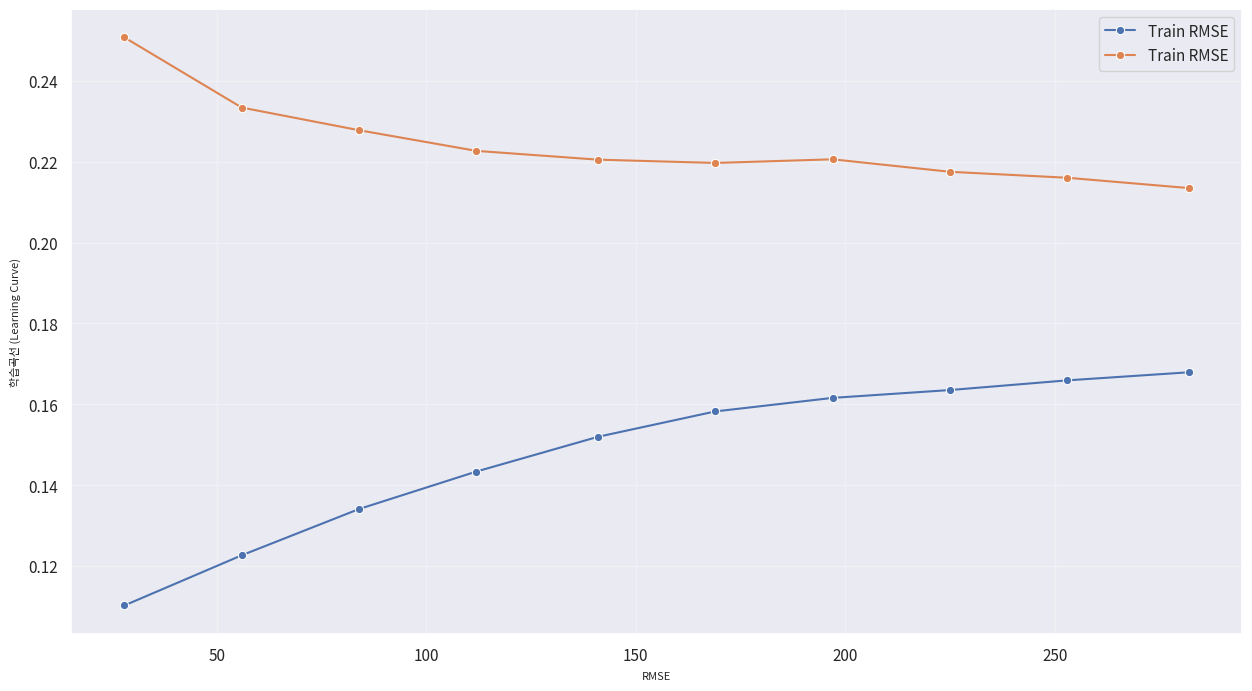

CPU times: total: 15.2 s
Wall time: 2min 18s


,결정계수(R2),평균절대오차(MAE),평균제곱오차(MSE),평균오차(RMSE),평균 절대 백분오차 비율(MAPE),평균 비율 오차(MPE),Train RMSE,CV RMSE 평균,CV RMSE 표준편차,Train/CV 비율,CV 변동성 비율,판정 결과
XGBRegressor,0.811,0.131,0.028,0.166,0.008,-0.007,0.168,0.213,0.015,0.787,0.069,⚠️ 과대적합 (variance 큼)


In [13]:
%%time

xgb = XGBRegressor(
    objective="reg:squarederror",
    random_state=52,
    n_jobs=-1,
    tree_method="hist"
)

# 실습 상황을 고려하여 하이퍼파라미터 탐색 범위를 축소
param_grid = {
    "n_estimators": [100, 300,500],
    "learning_rate": [0.01, 0.05, 0.1],
    "max_depth": [3, 5, 7],
    "subsample": [0.6, 0.8, 1.0],
    "colsample_bytree": [0.6, 0.8, 1.0],
    "reg_alpha": [0, 0.1, 1],
    "reg_lambda": [1, 5, 10],
}


gs = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1
)


gs.fit(x_train, y_train)


best_model = gs.best_estimator_

hs_get_score_cv(best_model, x_train, y_train, x, y)



#### 참고 | 윈도우와 mac 환경에서 차이 발생 가능

- 결정적 원인: GridSearchCV + n_jobs=-1 구조

- 파라미터 조합 탐색 순서가 OS마다 다름
  - 병렬 fold 평가 순서가 다름
  - 동일 score 근처 후보 중 “먼저 끝난 모델”이 best로 선택됨
  - 👉 best_estimator_ 자체가 서로 다름
  - mac: 덜 과적합된 최적점 위주로 선택
  - windows: train에 과도하게 맞춘 최적점을 선택

- 두 플랫폼 간 동일 결과를 얻기 위해서는 병렬성을 완전 제거해야 함
  - 모든 n_jobs 파라미터를 1로 설정해야 함

- 하지만 실험결과가 너무 미묘한 경우
  - 코인 토스 하나를 선택해야 한다면
  - 성능이 아니라 **CV 안정성 기준**을 우선해야 하므로
  - mac 결과 쪽이 해석상 더 합리적


## #04 변수 중요도 (Feature Importance)
XGBoost 만의 전용 계싼 로직 이므로 XGBoost 모형에 대해서만 적용된다
(LightGBM,CatBoost 는 값을 도출하는 함수식이 다르고, 해석 방식이나 도출되는 값 자체는 동일)

In [14]:
booster = best_model.get_booster()


#성능 기여도(중요도)
#get booster 로 booster 객체를 만들고,importance_type은 gainㄴ으로 설정.
#  즉 각각의 중요도로 변수별로 중요도가 뽑힘
imp=booster.get_score(importance_type='gain')
imp

{'visitors': 0.15667177736759186,
 'avg_price': 0.25182339549064636,
 'marketing_cost': 0.35250067710876465,
 'delivery_ratio': 0.13085459172725677,
 'rain_mm': 0.25934603810310364,
 'temperature': 0.12791459262371063,
 'holiday': 2.4490013122558594,
 'weekend': 2.6400489807128906}

#### Series 객체로 변환

In [15]:
import pandas as pd

imp_sr=pd.Series(imp)
imp_sr

visitors         0.157
avg_price        0.252
marketing_cost   0.353
delivery_ratio   0.131
rain_mm          0.259
temperature      0.128
holiday          2.449
weekend          2.640
dtype: float64

#### 모든 feature 이름을 인덱스로 갖는 빈 데이터 프레임 생성

In [16]:
imp_df = DataFrame(imp_sr,columns=['importance'])
imp_df=imp_df.sort_values('importance',ascending=False)
imp_df

,importance
weekend,2.640
holiday,2.449
marketing_cost,0.353
rain_mm,0.259
avg_price,0.252
visitors,0.157
delivery_ratio,0.131
temperature,0.128


#### 중요도 비율,누적합 추가

In [17]:
imp_df['ratio'] = imp_df['importance']/imp_df['importance'].sum()
imp_df['cumsum']=imp_df['ratio'].cumsum()
imp_df

,importance,ratio,cumsum
weekend,2.640,0.415,0.415
holiday,2.449,0.385,0.799
marketing_cost,0.353,0.055,0.854
rain_mm,0.259,0.041,0.895
avg_price,0.252,0.040,0.935
visitors,0.157,0.025,0.959
delivery_ratio,0.131,0.021,0.980
temperature,0.128,0.020,1.000


### [2] 변수 중요도 시각화


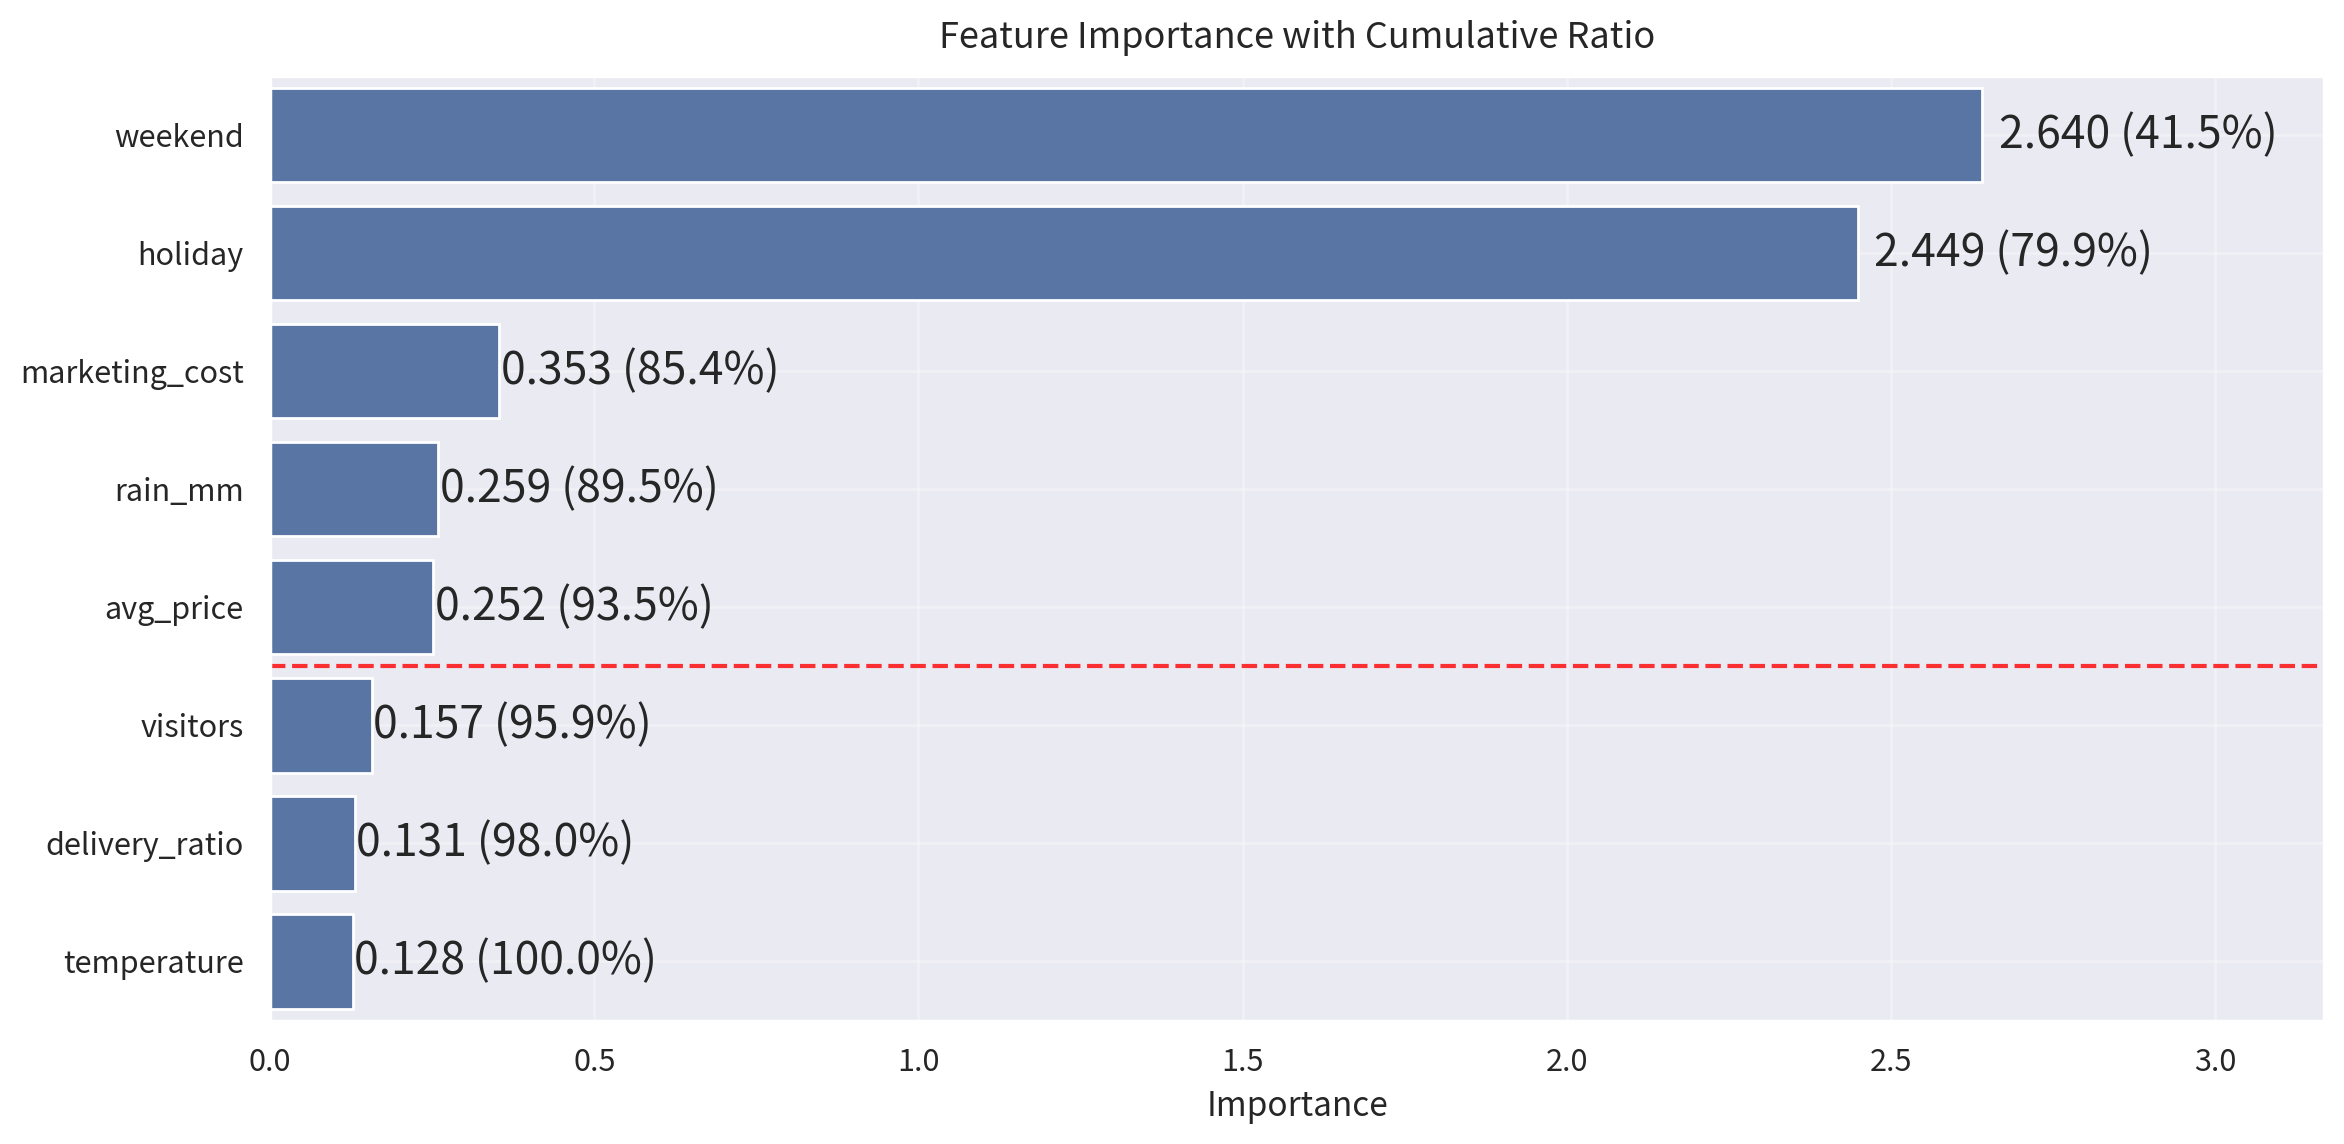

In [18]:


# imp_sr : feature importance Series (index = feature 이름)
imp_df = imp_sr.to_frame("importance").sort_values("importance", ascending=False)

# 중요도 비율
imp_df["ratio"] = imp_df["importance"] / imp_df["importance"].sum()

# 누적 비율
imp_df["cumsum"] = imp_df["ratio"].cumsum()

imp_df.head()



threshold = 0.9  # 90%

fig, ax = plt.subplots(figsize=(12, 6))

sb.barplot(data=imp_df, x="importance", y=imp_df.index, ax=ax)

# 막대 옆에 중요도 + 누적비율 표시
for i, (val, cum) in enumerate(zip(imp_df["importance"], imp_df["cumsum"])):
    ax.text(val * 1.01, i, f"{val:.3f} ({cum*100:.1f}%)", va="center")

# X축 범위 조금 늘리기
ax.set_xlim(0, imp_df["importance"].max() * 1.2)

# 90% 누적 지점 찾기
cut_idx = np.argmax(imp_df["cumsum"].values >= threshold)
cut_rank = cut_idx + 0.5

# 90% 지점 가로선
ax.axhline(y=cut_rank, linestyle="--", color="red", alpha=0.8)

ax.set_title("Feature Importance with Cumulative Ratio", fontsize=13, pad=10)
ax.set_xlabel("Importance")
ax.set_ylabel("")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

- 90% 를 기준으로 잘랐을 때, 변수가 너무 많으면 누적합 90% 기준의 변수들만 가지고 다시 한번 더 학습 모델 구축하는 것 추천

### [3] 변수 중요도 확인 함수 개선
- XGBoost 와 그 외의 경우를 통합하여 처리하도록 분기 처리 추가

In [19]:
def hs_feature_importance(model, X_train, y_train):
    if isinstance(model, XGBRegressor):
        booster = model.get_booster()
        imp = booster.get_score(importance_type="gain")
        imp_sr = Series(imp)
        imp_df = DataFrame(imp_sr, columns=['importance'])
    else:
        imp_df = permutation_importance(
            estimator=best_model,
            X=X_train,
            y=y_train,
            scoring="r2",
            n_repeats=30,
            random_state=42,
            n_jobs=-1,
        )

        # 결과 정리
        imp_df = DataFrame({"importance": imp_df.importances_mean},
                           index=X_train.columns)

    # 중요도 비율 + 누적중요도 계산
    imp_df["ratio"] = imp_df["importance"] / imp_df["importance"].sum()
    imp_df.sort_values("ratio", ascending=False, inplace=True)
    imp_df["cumsum"] = imp_df["ratio"].cumsum()

    # 시각화
    df = imp_df.sort_values(by="ratio", ascending=False)
    threshold = 0.9

    height = len(imp_df) * 60
    figsize = (1280 / 100, height / 100)
    fig, ax = plt.subplots(1, 1, figsize=figsize, dpi=my_dpi)

    sb.barplot(data=df, x="importance", y=df.index)

    # 값라벨 추가
    for i, v in enumerate(imp_df["importance"]):
        ax.text(
            v + 0.005,
            i,
            f"{v:.1f} ({imp_df.iloc[i]['cumsum']*100:.1f}%)",
            va="center"
        )

    ax.set_title("Feature Importance", fontsize=9)
    ax.set_xlabel("importance(cumsum)", fontsize=9)
    ax.set_ylabel(None)
    ax.grid(True, alpha=0.3)
    ax.set_xlim(0, imp_df["importance"].max() * 1.2)

    # 90% 처음 도달하는 인덱스 (0-based)
    cut_idx = np.argmax(imp_df["cumsum"].values >= threshold)

    # x축은 rank 기준으로 +1
    cut_rank = (int(cut_idx) + 1) - 0.5

    # 90% 도달지점 수직선 (핵심)
    plt.axhline(
        y=cut_rank,
        linestyle="--",
        color="red",
        alpha=0.8,
    )

    plt.tight_layout()
    plt.show()
    plt.close()

    return imp_df


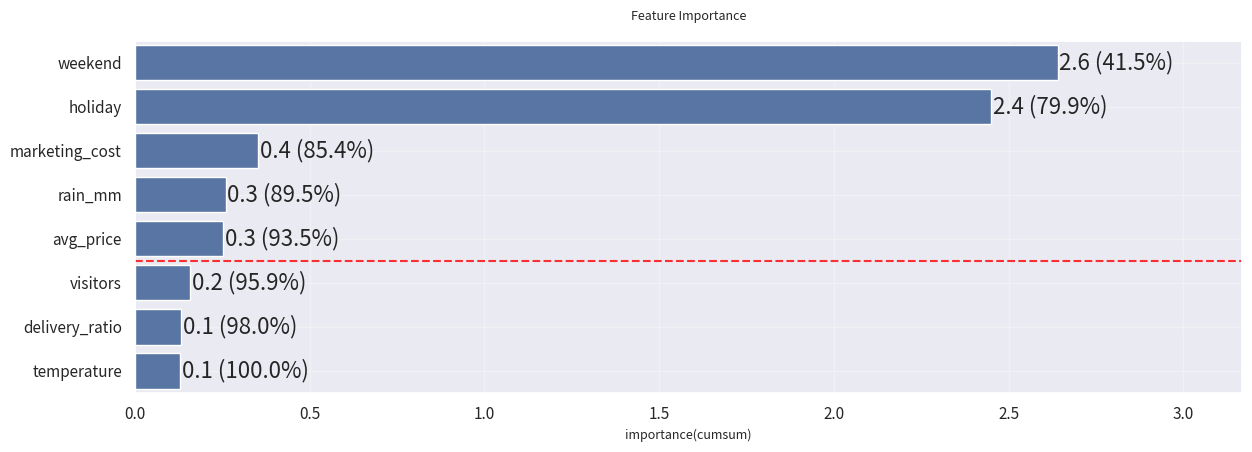

,importance,ratio,cumsum
weekend,2.640,0.415,0.415
holiday,2.449,0.385,0.799
marketing_cost,0.353,0.055,0.854
rain_mm,0.259,0.041,0.895
avg_price,0.252,0.040,0.935
visitors,0.157,0.025,0.959
delivery_ratio,0.131,0.021,0.980
temperature,0.128,0.020,1.000


In [20]:
hs_feature_importance(best_model,x_train,y_train)

## #05 SHAP 분석

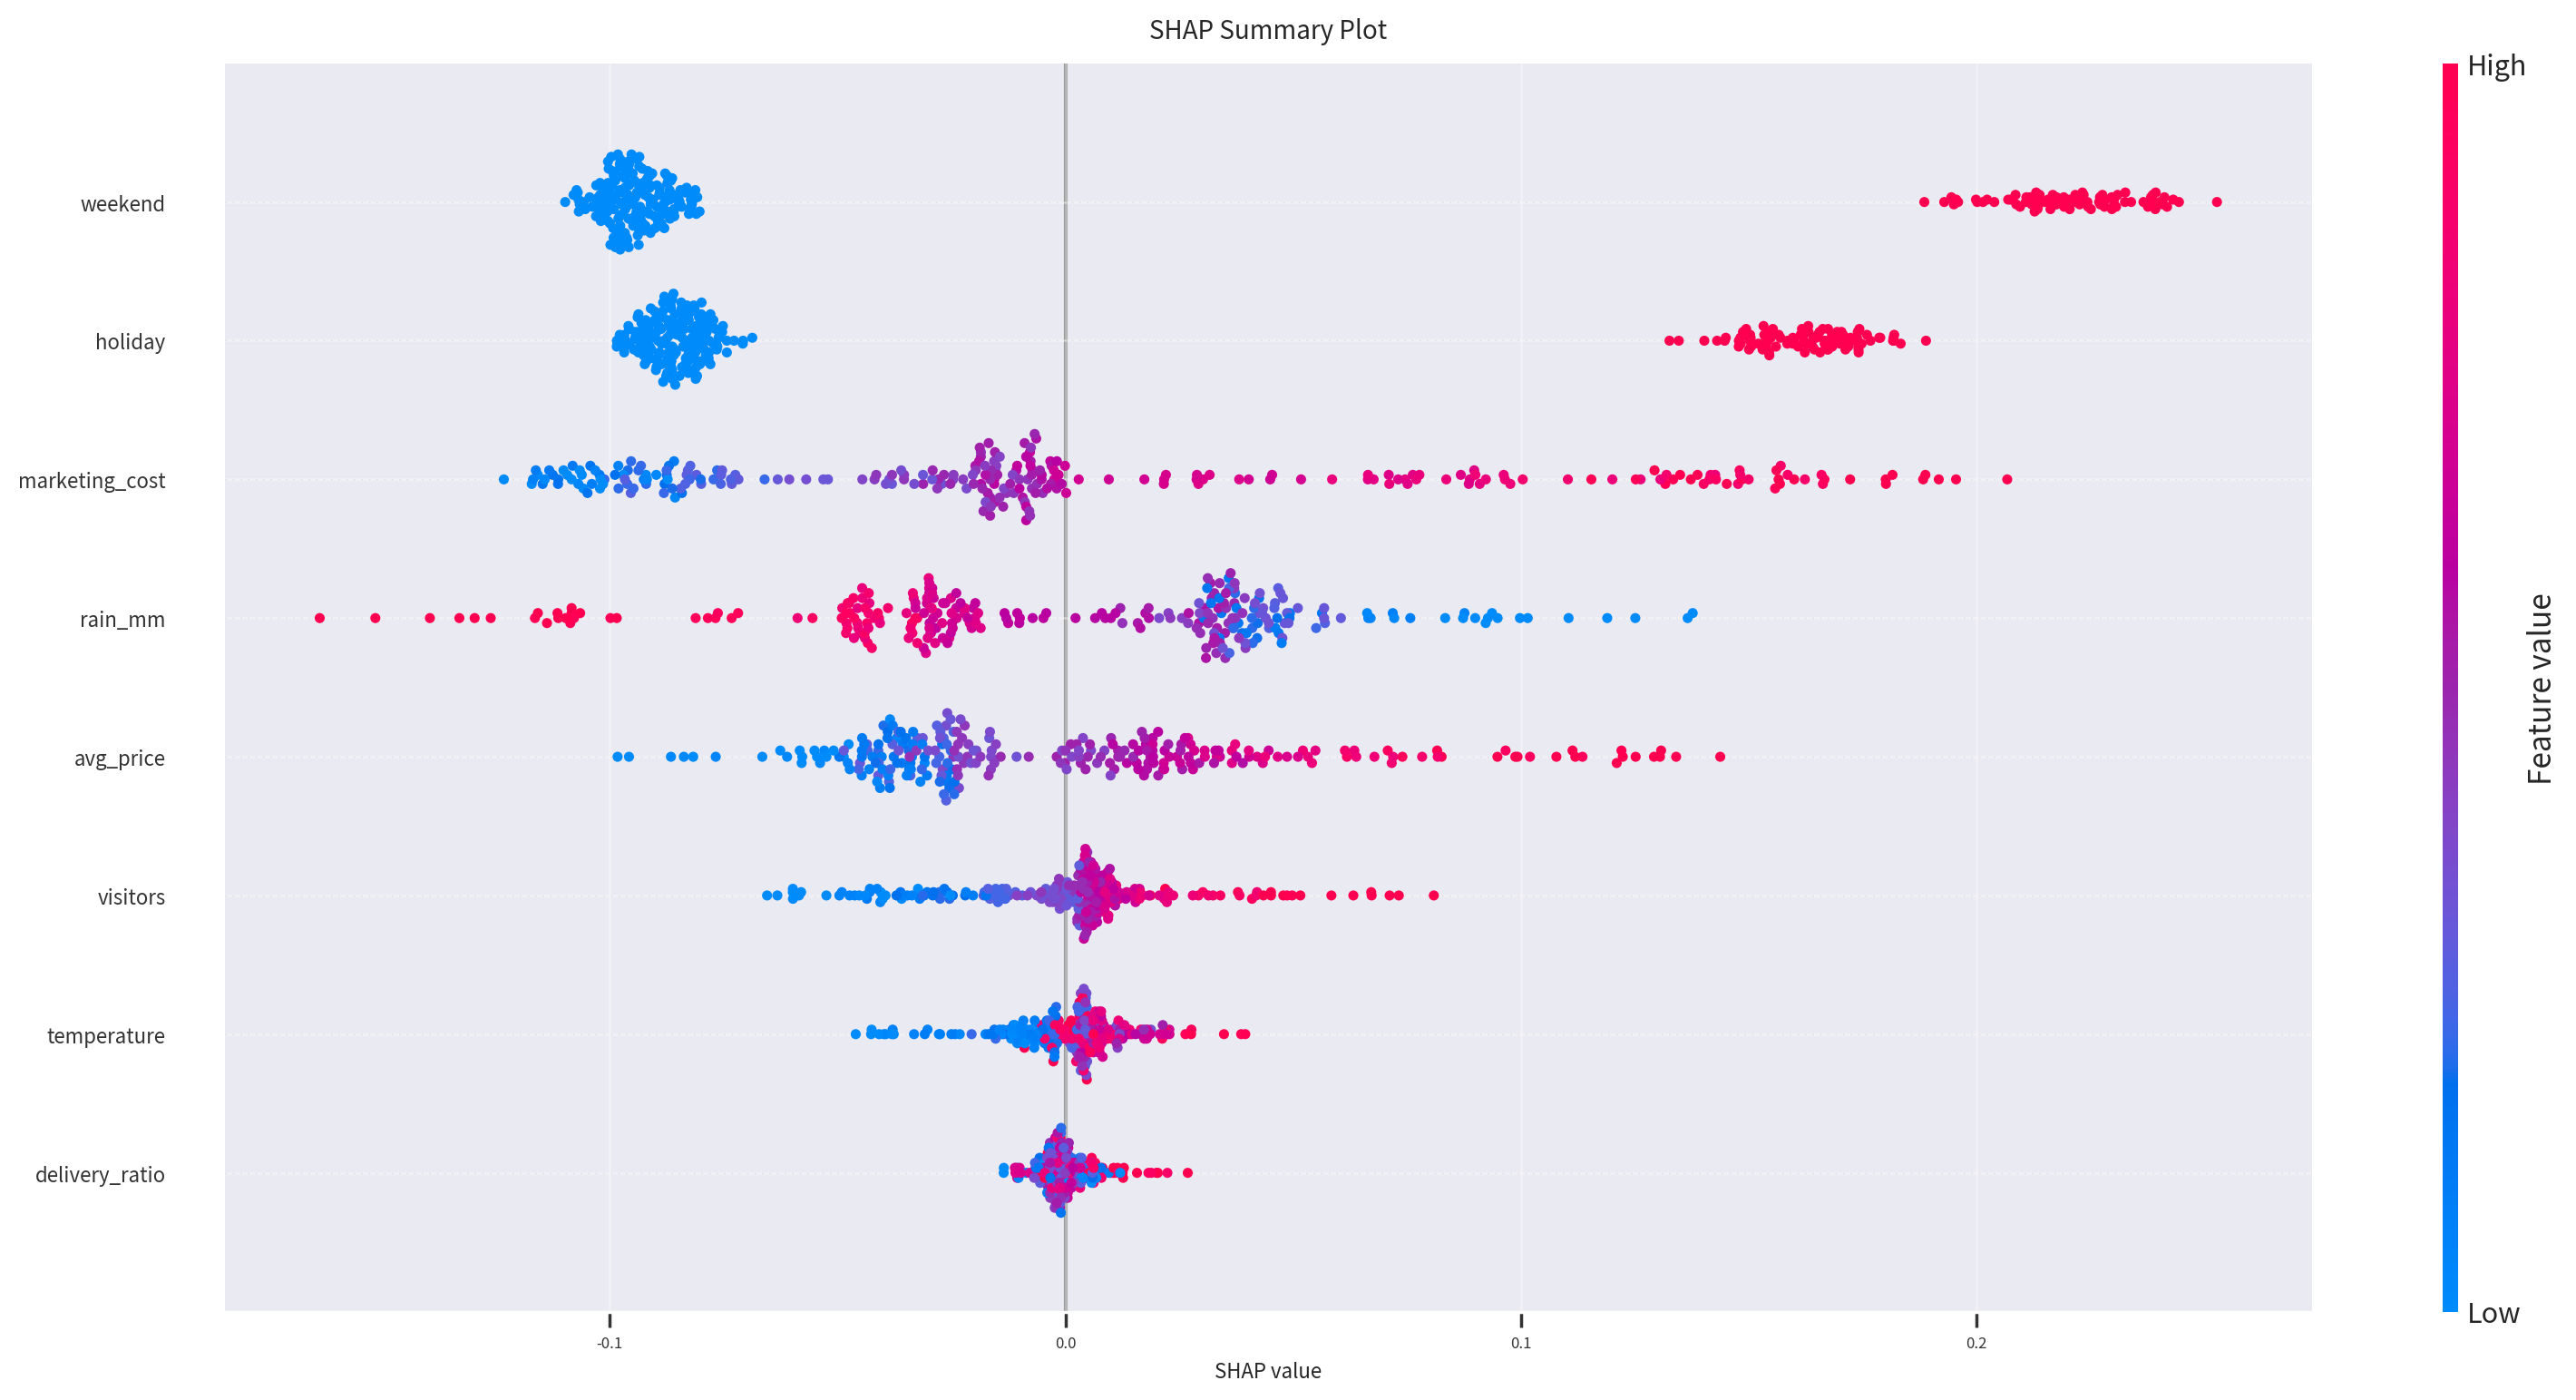

,feature,mean_abs_shap,mean_shap,std_shap,direction,cv,variability,importance_ratio,importance_cumsum,is_important
0,weekend,0.132,-0.000,0.145,음(-) 경향,1.096,variable,0.309,0.309,core
1,holiday,0.112,0.001,0.119,양(+) 경향,1.057,variable,0.263,0.572,core
2,marketing_cost,0.068,0.001,0.086,양(+) 경향,1.261,variable,0.160,0.731,core
3,rain_mm,0.046,-0.000,0.055,음(-) 경향,1.194,variable,0.107,0.838,secondary
4,avg_price,0.038,0.000,0.047,양(+) 경향,1.246,variable,0.089,0.927,secondary
5,visitors,0.017,-0.000,0.025,음(-) 경향,1.434,variable,0.041,0.968,secondary
6,temperature,0.010,0.001,0.013,양(+) 경향,1.386,variable,0.023,0.990,secondary
7,delivery_ratio,0.004,0.000,0.006,양(+) 경향,1.419,variable,0.010,1.000,secondary


In [21]:
import shap


result,_  =hs_shap_analysis(best_model,x_train)
result